In [1]:
# ============================================================
# Apache Arrow Zero-Copy Slicing Experiment
# ============================================================
#
# Goal:
# Prove that Arrow slicing is zero-copy.
#
# We compare:
#
# 1. Slice View
#    -> shares underlying buffers
#    -> no physical copy
#
# 2. Slice Copy
#    -> allocates new buffers
#    -> physically duplicates data
#
# Metrics:
# - Slice creation time
# - Peak memory allocation
# - Buffer sharing
# - Serialization time
# - Serialized payload size
#
# ============================================================

# ============================================================
# 1. Imports
# ============================================================

import pyarrow as pa
import pyarrow.ipc as ipc
import io
import time
import tracemalloc
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# ==============================================
# 1.5 Output Directories
# ==============================================

from pathlib import Path

# ------------------------------------------------
# Base project directory
# ------------------------------------------------

BASE_DIR = Path.cwd().parent

# ------------------------------------------------
# Results directory
# ------------------------------------------------

RESULTS_DIR = (
    BASE_DIR /
    "results" /
    "slicing"
)

GRAPHS_DIR = RESULTS_DIR / "graphs"
TABLES_DIR = RESULTS_DIR / "tables"
LOGS_DIR = RESULTS_DIR / "logs"

# ------------------------------------------------
# Create directories
# ------------------------------------------------

GRAPHS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

TABLES_DIR.mkdir(
    parents=True,
    exist_ok=True
)

LOGS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print(f"Results directory: {RESULTS_DIR}")


Results directory: /home/megh/arrow-ipc-analysis-linux/results/slicing


In [3]:
# ============================================================
# 2. Create Large Base Array
# ============================================================

print("="*80)
print("CREATING BASE ARRAY")
print("="*80)

base = pa.array(
    [1, 2, 3] * 2_000_000 +
    [None] * 500_000 +
    [4, 5, 6] * 2_000_000,
    type=pa.int32()
)

print(f"Base length     : {len(base):,}")
print(f"Base null count : {base.null_count:,}")

print("\nBase buffers:")

for i, buf in enumerate(base.buffers()):

    if buf is None:

        print(f"Buffer {i}: None")

    else:

        print(
            f"Buffer {i}: "
            f"{buf.size / 1024 / 1024:.2f} MB"
        )

CREATING BASE ARRAY
Base length     : 12,500,000
Base null count : 500,000

Base buffers:
Buffer 0: 1.49 MB
Buffer 1: 47.68 MB


In [4]:
# ============================================================
# 3. Create Zero-Copy Slice View
# ============================================================

print("\n" + "="*80)
print("CREATING ZERO-COPY SLICE VIEW")
print("="*80)

tracemalloc.start()

start = time.perf_counter()

slice_view = base.slice(
    2_000_000,
    2_000_000
)

view_creation_time = time.perf_counter() - start

view_peak_memory = tracemalloc.get_traced_memory()[1]

tracemalloc.reset_peak()

print(f"Slice view length : {len(slice_view):,}")

print(
    f"View creation time: "
    f"{view_creation_time:.8f}s"
)

print(
    f"Peak memory usage : "
    f"{view_peak_memory / 1024:.2f} KB"
)


CREATING ZERO-COPY SLICE VIEW
Slice view length : 2,000,000
View creation time: 0.00100753s
Peak memory usage : 18.82 KB


In [5]:
# ============================================================
# 4. Create Physical Copy
# ============================================================

print("\n" + "="*80)
print("CREATING PHYSICAL COPY")
print("="*80)

start = time.perf_counter()

# ------------------------------------------------------------
# Force physical duplication
# ------------------------------------------------------------

slice_copy = pa.array(
    slice_view.to_pylist(),
    type=pa.int32()
)

copy_creation_time = time.perf_counter() - start

copy_peak_memory = tracemalloc.get_traced_memory()[1]

tracemalloc.stop()

print(f"Copy length       : {len(slice_copy):,}")

print(
    f"Copy creation time: "
    f"{copy_creation_time:.8f}s"
)

print(
    f"Peak memory usage : "
    f"{copy_peak_memory / 1024:.2f} KB"
)


CREATING PHYSICAL COPY
Copy length       : 2,000,000
Copy creation time: 1.89208599s
Peak memory usage : 16782.12 KB


In [6]:
print("\n" + "="*80)
print("BUFFER SHARING ANALYSIS")
print("="*80)

base_buffers = base.buffers()

view_buffers = slice_view.buffers()

copy_buffers = slice_copy.buffers()

for i in range(len(base_buffers)):

    print(f"\nBuffer {i}")

    # --------------------------------------------------------
    # Base buffer info
    # --------------------------------------------------------

    print(f"Base  buffer : {base_buffers[i]}")
    print(f"View  buffer : {view_buffers[i]}")
    print(f"Copy  buffer : {copy_buffers[i]}")

    # --------------------------------------------------------
    # Handle None safely
    # --------------------------------------------------------

    if (
        base_buffers[i] is None or
        view_buffers[i] is None or
        copy_buffers[i] is None
    ):

        print("Skipping sharing comparison (None buffer).")

        continue

    # --------------------------------------------------------
    # Memory identity comparison
    # --------------------------------------------------------

    view_shared = (
        base_buffers[i].address ==
        view_buffers[i].address
    )

    copy_shared = (
        base_buffers[i].address ==
        copy_buffers[i].address
    )

    print(
        f"View shares memory : "
        f"{view_shared}"
    )

    print(
        f"Copy shares memory : "
        f"{copy_shared}"
    )


BUFFER SHARING ANALYSIS

Buffer 0
Base  buffer : <pyarrow.Buffer address=0x7ff334571000 size=1562500 is_cpu=True is_mutable=True>
View  buffer : <pyarrow.Buffer address=0x7ff334571000 size=1562500 is_cpu=True is_mutable=True>
Copy  buffer : None
Skipping sharing comparison (None buffer).

Buffer 1
Base  buffer : <pyarrow.Buffer address=0x7ff336541000 size=50000000 is_cpu=True is_mutable=True>
View  buffer : <pyarrow.Buffer address=0x7ff336541000 size=50000000 is_cpu=True is_mutable=True>
Copy  buffer : <pyarrow.Buffer address=0x7ff334701000 size=8000000 is_cpu=True is_mutable=True>
View shares memory : True
Copy shares memory : False


In [7]:
# ============================================================
# 6. Serialization Helper
# ============================================================

def serialize_array(arr):

    batch = pa.RecordBatch.from_arrays(
        [arr],
        names=["col"]
    )

    sink = io.BytesIO()

    writer = ipc.new_stream(
        sink,
        batch.schema
    )

    start = time.perf_counter()

    writer.write_batch(batch)

    writer.close()

    elapsed = time.perf_counter() - start

    size_mb = sink.tell() / 1024**2

    return elapsed, size_mb

In [8]:
# ============================================================
# 7. Serialize Slice View
# ============================================================

print("\n" + "="*80)
print("SERIALIZING SLICE VIEW")
print("="*80)

view_ser_time, view_ser_size = serialize_array(
    slice_view
)

print(
    f"Serialization time : "
    f"{view_ser_time:.6f}s"
)

print(
    f"Serialized size    : "
    f"{view_ser_size:.2f} MB"
)


SERIALIZING SLICE VIEW
CUSTOM IPC BUILD ACTIVE
Serialization time : 0.004634s
Serialized size    : 7.63 MB


In [9]:
# ============================================================
# 8. Serialize Physical Copy
# ============================================================

print("\n" + "="*80)
print("SERIALIZING PHYSICAL COPY")
print("="*80)

copy_ser_time, copy_ser_size = serialize_array(
    slice_copy
)

print(
    f"Serialization time : "
    f"{copy_ser_time:.6f}s"
)

print(
    f"Serialized size    : "
    f"{copy_ser_size:.2f} MB"
)


SERIALIZING PHYSICAL COPY
Serialization time : 0.001584s
Serialized size    : 7.63 MB
CUSTOM IPC BUILD ACTIVE


In [10]:
# ============================================================
# 9. Results Table
# ============================================================

results_df = pd.DataFrame({

    "Case": [
        "Slice View",
        "Physical Copy"
    ],

    "Creation_Time_s": [
        view_creation_time,
        copy_creation_time
    ],

    "Peak_Memory_KB": [
        view_peak_memory / 1024,
        copy_peak_memory / 1024
    ],

    "Serialization_Time_s": [
        view_ser_time,
        copy_ser_time
    ],

    "Serialized_Size_MB": [
        view_ser_size,
        copy_ser_size
    ]
})

print("\n" + "="*80)
print("FINAL RESULTS")
print("="*80)

results_df


FINAL RESULTS


,Case,Creation_Time_s,Peak_Memory_KB,Serialization_Time_s,Serialized_Size_MB
0,Slice View,0.001008,18.822266,0.004634,7.629662
1,Physical Copy,1.892086,16782.119141,0.001584,7.629662


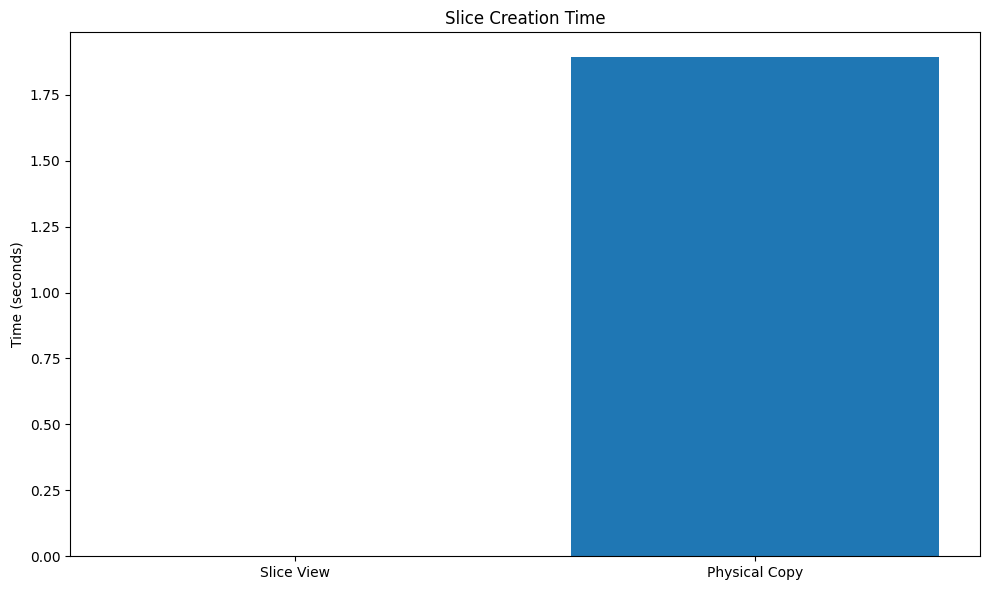

In [11]:
# ============================================================
# 10. Creation Time Visualization
# ============================================================

plt.figure(figsize=(10, 6))

plt.bar(
    results_df["Case"],
    results_df["Creation_Time_s"]
)

plt.title("Slice Creation Time")

plt.ylabel("Time (seconds)")

plt.tight_layout()

plt.savefig( GRAPHS_DIR / "creation_time.png", dpi=300, bbox_inches="tight" ) 
plt.show()

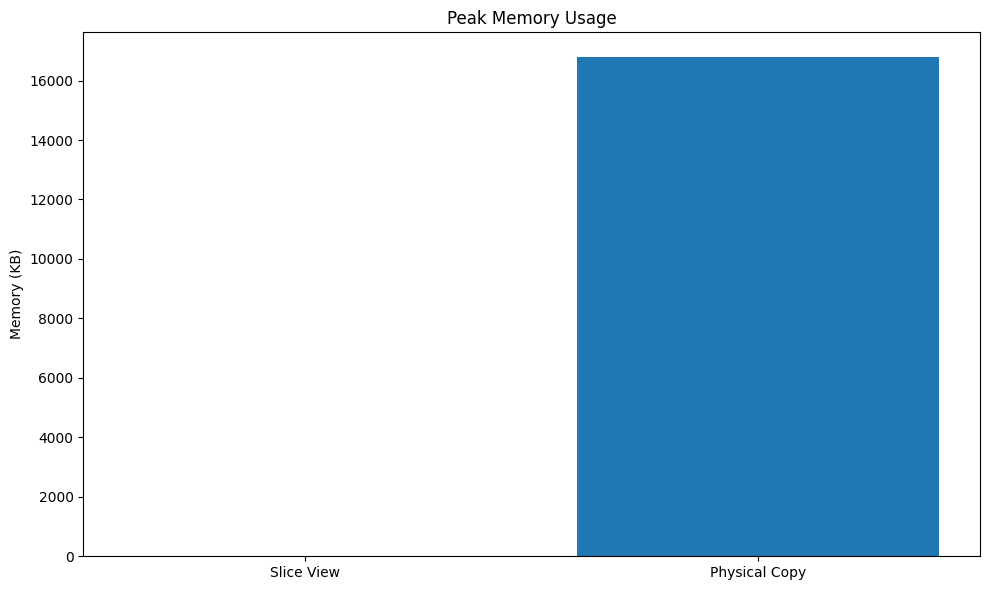

In [12]:
# ============================================================
# 11. Peak Memory Visualization
# ============================================================

plt.figure(figsize=(10, 6))

plt.bar(
    results_df["Case"],
    results_df["Peak_Memory_KB"]
)

plt.title("Peak Memory Usage")

plt.ylabel("Memory (KB)")

plt.tight_layout()

plt.savefig(
    GRAPHS_DIR / "peak_memory.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


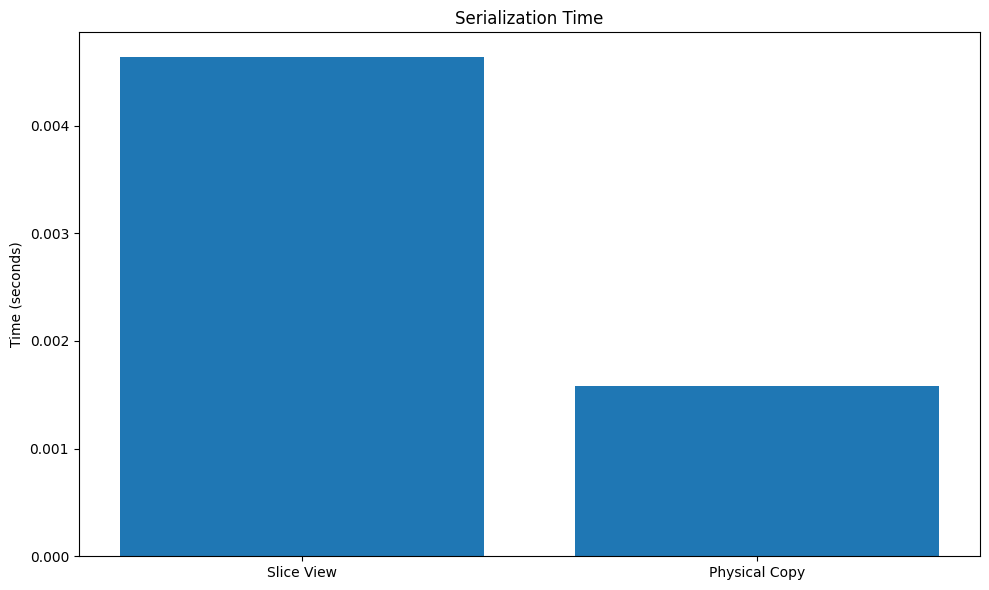

In [13]:
# ============================================================
# 12. Serialization Time Visualization
# ============================================================

plt.figure(figsize=(10, 6))

plt.bar(
    results_df["Case"],
    results_df["Serialization_Time_s"]
)

plt.title("Serialization Time")

plt.ylabel("Time (seconds)")

plt.tight_layout()

plt.savefig(
    GRAPHS_DIR / "serialization_time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


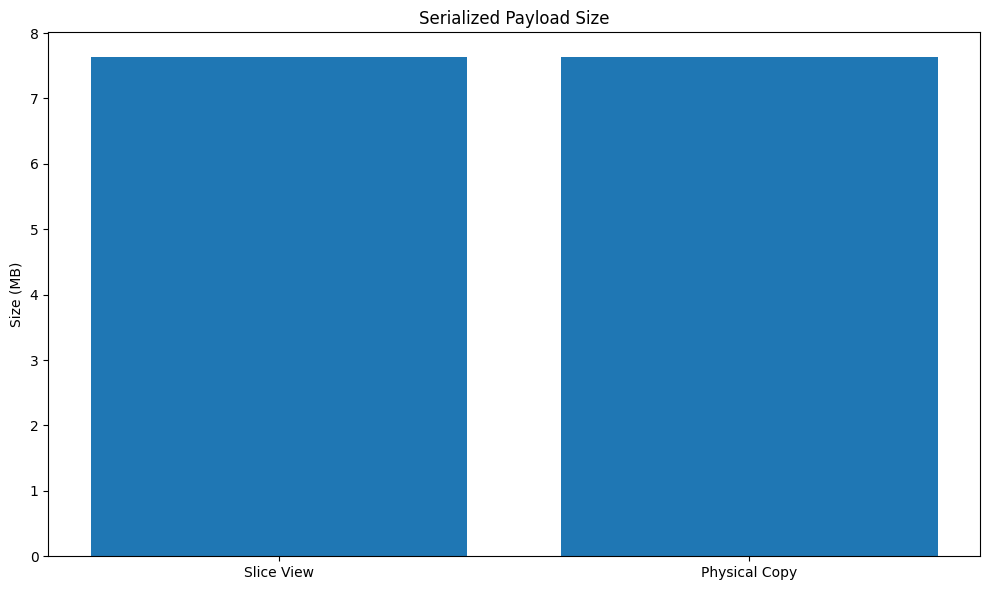

In [14]:
# ============================================================
# 13. Serialized Size Visualization
# ============================================================

plt.figure(figsize=(10, 6))

plt.bar(
    results_df["Case"],
    results_df["Serialized_Size_MB"]
)

plt.title("Serialized Payload Size")

plt.ylabel("Size (MB)")

plt.tight_layout()

plt.savefig( GRAPHS_DIR / "serialized_size.png", dpi=300, bbox_inches="tight" ) 
plt.show()

In [15]:
```python
# ==============================================
# 14. Save Results
# ==============================================

results_csv_path = (
    TABLES_DIR /
    "zero_copy_slicing_results.csv"
)

results_df.to_csv(
    results_csv_path,
    index=False
)

print(
    f"\nResults saved to:\n{results_csv_path}"
)
```


SyntaxError: invalid syntax (281434721.py, line 1)

In [ ]:
```python
# ==============================================
# 15. Save Summary Log
# ==============================================

summary_log_path = (
    LOGS_DIR /
    "summary.txt"
)

with open(summary_log_path, "w") as f:

    f.write("="*80 + "\n")
    f.write("ZERO-COPY SLICING EXPERIMENT SUMMARY\n")
    f.write("="*80 + "\n\n")

    f.write(results_df.to_string())

print(
    f"\nSummary log saved to:\n{summary_log_path}"
)
```
